# Pricing Analytique Black-Scholes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

On créer une fonction qui prendra pour le test comme paramètres :
- S0 = 180
- K = 185 (strike => option "Out-of-the-Money")
- T = 0.5  (maturité dans 6 mois)
- r = 0.04 (taux sans risque de 4%)
- sigma = 0.25 (volatilité implicite de 25%)

Pour la coder il faut connaître la formule  du prix d'un call européen :
- $Call=S_0\mathcal{N}(d_1)-Ke^{-rT}\mathcal{N}(d_2)$ avec
    - $d_1=\frac{ln(S0/K)+(r+\frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$
    - $d_2=\frac{ln(S0/K)+(r-\frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$
    - ainsi $d_2=d_1-\sigma \sqrt{T}$

In [2]:
def bs_call_price(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + (sigma**2) / 2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma*np.sqrt(T))

    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    
    return call_price

In [3]:
S0 = 180
K = 185
T = 0.5
r = 0.04
sigma = 0.25

prix = bs_call_price(S0, K, T, r, sigma)
print(f"Prix du call : {prix:.2f} $")

Prix du call : 12.07 $


Traçons des graphiques de sensibilité (prix de l'option vs prix de l'action et prix de l'option vs volatilité)

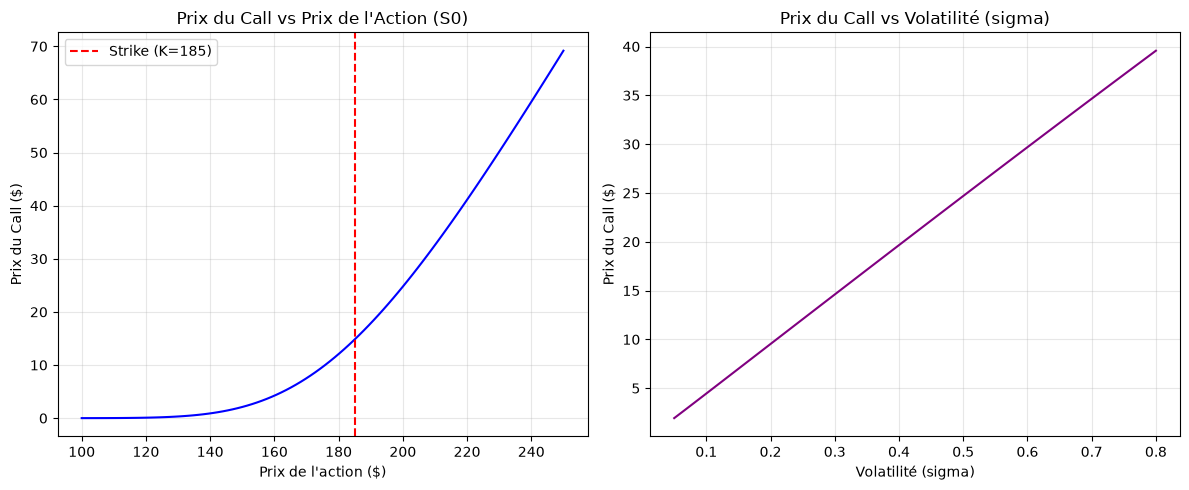

In [4]:
# Sensibilité au prix du sous-jacent (S0)
S_values = np.linspace(100, 250, 100)
call_prices_S = [bs_call_price(S, K=185, T=0.5, r=0.04, sigma=0.25) for S in S_values]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(S_values, call_prices_S, color='blue')
plt.axvline(x=185, color='red', linestyle='--', label="Strike (K=185)")
plt.title("Prix du Call vs Prix de l'Action (S0)")
plt.xlabel("Prix de l'action ($)")
plt.ylabel("Prix du Call ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Sensibilité à la volatilité (sigma)
sigma_values = np.linspace(0.05, 0.80, 50)
call_prices_sigma = [bs_call_price(S0=180, K=185, T=0.5, r=0.04, sigma=sig) for sig in sigma_values]

plt.subplot(1, 2, 2)
plt.plot(sigma_values, call_prices_sigma, color='purple')
plt.title("Prix du Call vs Volatilité (sigma)")
plt.xlabel("Volatilité (sigma)")
plt.ylabel("Prix du Call ($)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Regardons maintenant ce que l'on a pour un put européen : 
- $Put=Ke^{-rT}\mathcal{N}(-d_2)-S_0\mathcal{N}(-d_1)$

On remarque que : $Call-Put=S_0-Ke^{-rT}$, ainsi le calcul du call permet d'avoir plus simplement le put

In [5]:
def bs_put_price(S0, K, T, r, sigma):
    price_call = bs_call_price(S0, K, T, r, sigma)

    price_put = price_call - S0 + K * np.exp(-r * T)

    return price_put

In [6]:
# on prend les mêmes paramètres que pour le call
prix = bs_put_price(S0, K, T, r, sigma)
print(f"Prix du put : {prix:.2f} $")

Prix du put : 13.40 $


Le fait de calculer le put comme cela permet de garder la parité call-put car si on l'avait recalculer de rien on aurait surement eu des erreurs de virgule flottante

On test les Greeks créés dans src/options_pricer.py :

In [7]:
import sys
import os
# On ajoute le dossier racine du projet au "path" de Python
sys.path.append(os.path.abspath('..'))

from src.options_pricer import BlackScholesPricer

# on réinitie même si déjà fait
S0, K, T, r, sigma = 180.0, 185.0, 0.5, 0.04, 0.25
pricer = BlackScholesPricer(S0, K, T, r, sigma)

delta_call = pricer.delta(option_type='call')
delta_put = pricer.delta(option_type='put')
gamma = pricer.gamma()
vega = pricer.vega()
theta_call = pricer.theta(option_type='call')
theta_put = pricer.theta(option_type='put')

print("--- TABLEAU DE BORD DES RISQUES (GRECQUES) : CALL ---")
print(f"Prix du Call : {pricer.call_price():.4f} $")
print(f"Delta (Δ)    : {delta_call:.4f} (Probabilité d'exercice / Exposition directionnelle)")
print(f"Gamma (Γ)    : {gamma:.4f} (Accélération du Delta)")
print(f"Vega (ν)     : {vega:.4f} $ (Gain si la volatilité augmente de 1%)")
print(f"Theta (Θ)    : {theta_call:.4f} $ (Perte de valeur par jour qui passe)")
print("\n--- TABLEAU DE BORD DES RISQUES (GRECQUES) : PUT ---")
print(f"Prix du Put : {pricer.put_price():.4f} $")
print(f"Delta (Δ)    : {delta_put:.4f} (Probabilité d'exercice / Exposition directionnelle)")
print(f"Gamma (Γ)    : {gamma:.4f} (Accélération du Delta)")
print(f"Vega (ν)     : {vega:.4f} $ (Gain si la volatilité augmente de 1%)")
print(f"Theta (Θ)    : {theta_put:.4f} $ (Perte de valeur par jour qui passe)")

--- TABLEAU DE BORD DES RISQUES (GRECQUES) : CALL ---
Prix du Call : 12.0676 $
Delta (Δ)    : 0.5186 (Probabilité d'exercice / Exposition directionnelle)
Gamma (Γ)    : 0.0125 (Accélération du Delta)
Vega (ν)     : 0.5072 $ (Gain si la volatilité augmente de 1%)
Theta (Θ)    : -0.0436 $ (Perte de valeur par jour qui passe)

--- TABLEAU DE BORD DES RISQUES (GRECQUES) : PUT ---
Prix du Put : 13.4043 $
Delta (Δ)    : -0.4814 (Probabilité d'exercice / Exposition directionnelle)
Gamma (Γ)    : 0.0125 (Accélération du Delta)
Vega (ν)     : 0.5072 $ (Gain si la volatilité augmente de 1%)
Theta (Θ)    : -0.0238 $ (Perte de valeur par jour qui passe)


On retrouve de manière itérative une estimation de la volatilité implicite grâce à la valeur du marché

In [8]:
# Recherche de la Volatilité Implicite
market_price_call = 15.00
iv_call = BlackScholesPricer.implied_volatility(
    market_price=market_price_call,
    S0=180, K=185, T=0.5, r=0.04, option_type='call'
)

print(f"Pour justifier un prix de {market_price_call}$, la Volatilité Implicite du marché est de : {iv_call*100:.2f}%")

Pour justifier un prix de 15.0$, la Volatilité Implicite du marché est de : 30.79%
